# 04. pH: separating adsorption from hydroxide precipitation

At pH 9 and 11 this experiment removed more than 90% of both metals from
solution. That is the best-looking number anywhere in the dataset, and it is
the one result that should not be reported as adsorption.

Metal hydroxides precipitate above a pH that depends on their solubility
product and on how concentrated the solution is. Any precipitate formed in the
flask would be caught on the filter paper along with the peel, and would be
counted as removal. No adsorbent-free controls were run at each pH, so the two
mechanisms cannot be separated by experiment.

They can, however, be screened by calculation.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from adsorption import concentration, removal_pct

raw = pd.read_csv("data/aas_readings.csv")
CONTROL = {m: float(concentration(
    raw.loc[(raw.series == "control") & (raw.metal == m), "reading_mg_L"].iloc[0],
    raw.loc[(raw.series == "control") & (raw.metal == m), "dilution_factor"].iloc[0]))
    for m in ["Mn", "Zn"]}

ph = raw[raw.series == "pH"].copy()
ph["Ce"] = concentration(ph["reading_mg_L"], ph["dilution_factor"])
ph["apparent_removal_pct"] = [removal_pct(CONTROL[m], ce)
                              for m, ce in zip(ph.metal, ph.Ce)]

print(ph[["metal", "label", "pH_initial", "dilution_factor", "reading_mg_L",
          "Ce", "apparent_removal_pct"]].round(2).to_string(index=False))

metal       label  pH_initial  dilution_factor  reading_mg_L     Ce  apparent_removal_pct
   Mn        pH_3         3.0             10.0         12.56 125.60                  4.12
   Mn        pH_5         5.0             10.0         11.61 116.10                 11.37
   Mn  pH_7_first         7.0             10.0         12.79 127.90                  2.37
   Mn pH_7_second         7.0             10.0         10.50 105.00                 19.85
   Mn        pH_9         9.0              1.0         10.42  10.42                 92.05
   Mn       pH_11        11.0              1.0          8.44   8.44                 93.56
   Zn        pH_3         3.0             50.0          2.30 115.15                 19.50
   Zn        pH_5         5.0             50.0          2.26 112.95                 21.04
   Zn  pH_7_first         7.0             50.0          1.59  79.55                 44.39
   Zn pH_7_second         7.0             50.0          0.70  35.05                 75.50
   Zn     

## Where precipitation is expected to begin

For a divalent metal hydroxide,

$$K_{sp} = [M^{2+}][OH^-]^2 \quad\Rightarrow\quad
[OH^-] = \sqrt{K_{sp}/[M^{2+}]}$$

and the onset pH follows from `pH = 14 + log10[OH-]` at 25 C. The relevant
concentration is the measured control, not the nominal 400 mg/L, because
notebook 00 showed those differ by a factor of about three.

Solubility products vary between sources, so these are screening estimates.
They show where precipitation *could* begin; they do not prove it occurred.

In [2]:
KSP = {"Zn": 3.5e-17,   # Reichle, McCurdy & Hepler (1975)
       "Mn": 2.0e-13}    # standard table of solubility products
MOLAR_MASS = {"Zn": 65.38, "Mn": 54.938}

def onset_pH(metal, mg_per_L):
    molar = mg_per_L / 1000.0 / MOLAR_MASS[metal]
    oh = np.sqrt(KSP[metal] / molar)
    return 14.0 + np.log10(oh)

onset = {}
for metal in ["Zn", "Mn"]:
    conc_mg_L = CONTROL[metal]
    onset[metal] = onset_pH(metal, conc_mg_L)
    molar = conc_mg_L / 1000 / MOLAR_MASS[metal]
    print(f"{metal}(II): measured {conc_mg_L:.1f} mg/L = {molar:.2e} mol/L")
    print(f"          Ksp = {KSP[metal]:.1e}, onset pH = {onset[metal]:.1f}")
    print()

print("Zn(OH)2 can begin to form near pH 7.1 and Mn(OH)2 near pH 9.0 at these")
print("concentrations. Both pH 9 and pH 11 sit above both thresholds.")

Zn(II): measured 143.1 mg/L = 2.19e-03 mol/L
          Ksp = 3.5e-17, onset pH = 7.1

Mn(II): measured 131.0 mg/L = 2.38e-03 mol/L
          Ksp = 2.0e-13, onset pH = 9.0

Zn(OH)2 can begin to form near pH 7.1 and Mn(OH)2 near pH 9.0 at these
concentrations. Both pH 9 and pH 11 sit above both thresholds.


Even a tenfold error in the concentration moves the onset pH by only
about half a unit, so the conclusion is not sensitive to the
concentration uncertainty carried from notebook 00.


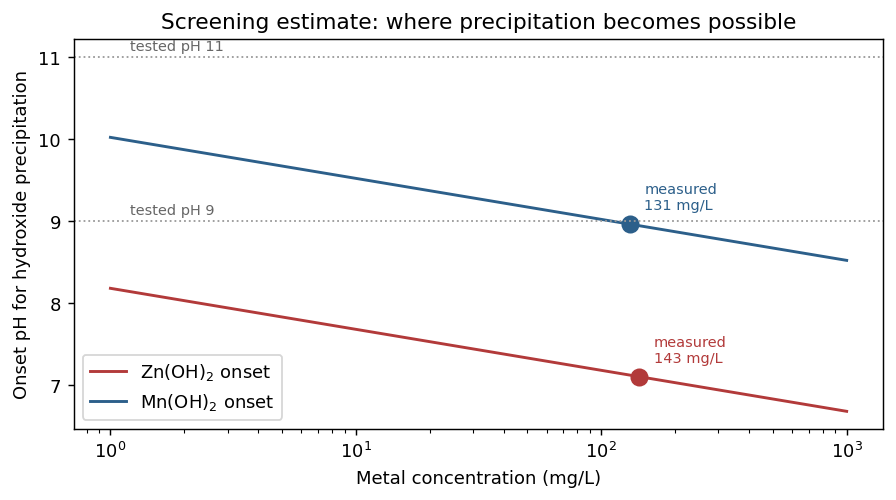

In [3]:
# How sensitive is the threshold to the concentration uncertainty?
grid = np.logspace(0, 3, 200)
fig, ax = plt.subplots(figsize=(7, 4.0))
for metal, colour in [("Zn", "#b23a3a"), ("Mn", "#2c5f8a")]:
    ax.plot(grid, onset_pH(metal, grid), color=colour, lw=1.6,
            label=f"{metal}(OH)$_2$ onset")
    ax.plot([CONTROL[metal]], [onset[metal]], "o", color=colour, ms=9)
    ax.annotate(f"measured\n{CONTROL[metal]:.0f} mg/L",
                (CONTROL[metal], onset[metal]),
                textcoords="offset points", xytext=(8, 8), fontsize=8,
                color=colour)
for tested in [9, 11]:
    ax.axhline(tested, color="#999999", ls=":", lw=1)
    ax.text(1.2, tested + 0.08, f"tested pH {tested}", fontsize=8,
            color="#666666")
ax.set_xscale("log")
ax.set_xlabel("Metal concentration (mg/L)")
ax.set_ylabel("Onset pH for hydroxide precipitation")
ax.set_title("Screening estimate: where precipitation becomes possible")
ax.legend()
fig.tight_layout()

print("Even a tenfold error in the concentration moves the onset pH by only")
print("about half a unit, so the conclusion is not sensitive to the")
print("concentration uncertainty carried from notebook 00.")

## A second problem with the high-pH points

The pH 9 and 11 samples were measured undiluted, while the control was measured
at a dilution. The dilution factor no longer cancels, so these removals depend
entirely on the inferred `reading x DF` convention. If those samples had in
fact been diluted like the rest, the same readings would give a completely
different answer.

In [4]:
print(f"{'metal':6s} {'pH':>4s} {'reading':>8s}  "
      f"{'removal as reported':>20s}  {'removal if diluted like control':>32s}")
for _, row in ph[ph.pH_initial.isin([9, 11])].iterrows():
    metal = row["metal"]
    as_reported = removal_pct(CONTROL[metal], row["reading_mg_L"] * 1.0)
    alt_df = 10 if metal == "Mn" else 50
    alternative = removal_pct(CONTROL[metal], row["reading_mg_L"] * alt_df)
    print(f"{metal:6s} {row['pH_initial']:4.0f} {row['reading_mg_L']:8.2f}  "
          f"{as_reported:19.1f}%  {alternative:31.1f}%")
print()
print("Under the alternative reading the same four samples give -16% to 36%")
print("instead of 92% to 98%. Two independent reasons, chemical and")
print("analytical, to exclude the high-pH points from any adsorption claim.")

metal    pH  reading   removal as reported   removal if diluted like control
Mn        9    10.42                 92.0%                             20.5%
Mn       11     8.44                 93.6%                             35.6%
Zn        9     3.32                 97.7%                            -15.9%
Zn       11     2.63                 98.2%                              8.1%

Under the alternative reading the same four samples give -16% to 36%
instead of 92% to 98%. Two independent reasons, chemical and
analytical, to exclude the high-pH points from any adsorption claim.


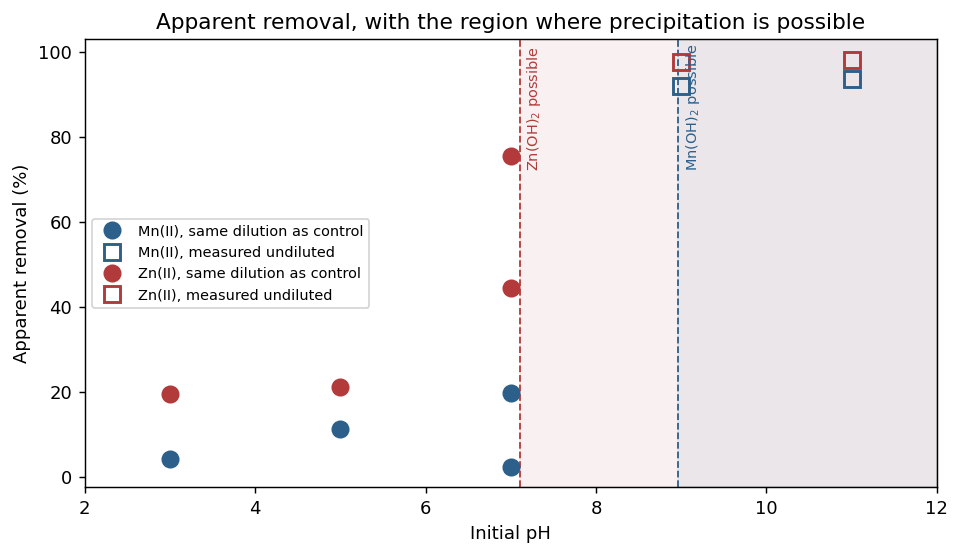

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.axvspan(onset["Zn"], 12, color="#b23a3a", alpha=0.07)
ax.axvspan(onset["Mn"], 12, color="#2c5f8a", alpha=0.07)
ax.axvline(onset["Zn"], color="#b23a3a", ls="--", lw=1)
ax.axvline(onset["Mn"], color="#2c5f8a", ls="--", lw=1)
ax.text(onset["Zn"] + 0.07, 72, "Zn(OH)$_2$ possible", fontsize=8,
        color="#b23a3a", rotation=90, va="bottom")
ax.text(onset["Mn"] + 0.07, 72, "Mn(OH)$_2$ possible", fontsize=8,
        color="#2c5f8a", rotation=90, va="bottom")

for metal, colour in [("Mn", "#2c5f8a"), ("Zn", "#b23a3a")]:
    d = ph[ph.metal == metal]
    same = d[d.dilution_factor > 1]
    direct = d[d.dilution_factor == 1]
    ax.plot(same.pH_initial, same.apparent_removal_pct, "o", color=colour,
            ms=9, label=f"{metal}(II), same dilution as control")
    ax.plot(direct.pH_initial, direct.apparent_removal_pct, "s", mfc="none",
            mec=colour, ms=9, mew=1.6,
            label=f"{metal}(II), measured undiluted")

ax.set_xlabel("Initial pH")
ax.set_ylabel("Apparent removal (%)")
ax.set_xlim(2, 12)
ax.set_title("Apparent removal, with the region where precipitation is possible")
ax.legend(fontsize=8, loc="center left")
fig.tight_layout()

## The defensible range

Below pH 7 neither hydroxide can form at these concentrations, and the samples
share the control's dilution, so both objections fall away.

In [6]:
clean = ph[ph.pH_initial <= 5]
print(clean[["metal", "pH_initial", "apparent_removal_pct"]].round(1)
      .to_string(index=False))
print()
for metal in ["Zn", "Mn"]:
    d = clean[clean.metal == metal]
    best = d.loc[d.apparent_removal_pct.idxmax()]
    print(f"{metal}(II): highest defensible removal "
          f"{best.apparent_removal_pct:.1f}% at pH {best.pH_initial:.0f}")
print()
print("Both rise from pH 3 to pH 5, which is consistent with less competition")
print("from H+ for the same binding sites as acidity falls.")
print()
print("The pH 7 points are left unresolved: the laboratory reported two")
print("differently labelled pH 7 readings per metal and their identities are")
print("not documented.")
seven = ph[ph.pH_initial == 7]
print(seven[["metal", "label", "reading_mg_L",
             "apparent_removal_pct"]].round(1).to_string(index=False))
print()
print("For Mn(II) the two readings give 2.4% and 19.8%. Picking the higher one")
print("would produce a better-looking pH optimum with no way to justify the")
print("choice, so neither is used.")

metal  pH_initial  apparent_removal_pct
   Mn         3.0                   4.1
   Mn         5.0                  11.4
   Zn         3.0                  19.5
   Zn         5.0                  21.0

Zn(II): highest defensible removal 21.0% at pH 5
Mn(II): highest defensible removal 11.4% at pH 5

Both rise from pH 3 to pH 5, which is consistent with less competition
from H+ for the same binding sites as acidity falls.

The pH 7 points are left unresolved: the laboratory reported two
differently labelled pH 7 readings per metal and their identities are
not documented.
metal       label  reading_mg_L  apparent_removal_pct
   Mn  pH_7_first          12.8                   2.4
   Mn pH_7_second          10.5                  19.8
   Zn  pH_7_first           1.6                  44.4
   Zn pH_7_second           0.7                  75.5

For Mn(II) the two readings give 2.4% and 19.8%. Picking the higher one
would produce a better-looking pH optimum with no way to justify the
choice, so n

## Conclusions

- The 92 to 98% apparent removals at pH 9 and 11 cannot be attributed to
  adsorption. Zn(OH)2 can precipitate above about pH 7.1 and Mn(OH)2 above
  about pH 9.0 at the measured concentrations, and any precipitate would be
  retained on the filter paper.
- Those same points were measured on a different analytical basis from the
  control, so their removals also depend on the dilution convention. Under the
  alternative convention they range from -16% to 36%.
- The defensible results are 21.0% for Zn(II) and 11.4% for Mn(II), both at
  pH 5, with the pH 7 readings left unresolved.
- The fix is cheap and is recommendation 7 in the thesis: run an adsorbent-free
  flask at every pH, and record the final pH as well as the initial one. A
  blank at pH 9 would have settled this in one afternoon.

A 98% removal headline was available here. It would have been wrong.